# Prophet Forecasting Playground

This notebook provides an interactive environment to test the cluster-based Prophet model adapted for Retail Demand Forecasting.

### Key Features
- **Retail Specific**: Uses `np.log1p` transformation and Ridge-like Prophet configurations to handle extreme demand skewness.
- **Cluster-based**: Fits independent Prophet models for each `profile_cluster_id`.
- **Symmetric Evaluation**: Evaluates performance using SMAPE and MAE, which are robust to zero-demand weeks.
- **Modular Architecture**: Uses decoupled functions from `src/models/prophet_model.py`.


## 0. Environment Setup

Resolve project-level modules from the `src` directory and load the necessary forecasting functions.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized Prophet functions
from src.models.prophet_model import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_prophet_artifacts
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

print("Setup complete. Local prophet modules loaded from src/.")

Importing plotly failed. Interactive plots will not work.


Setup complete. Local prophet modules loaded from src/.


## 1. Global Data Loading

We load the global processed dataset once. It contains all features, including the raw consumption and weather signals that will be scaled differently depending on the forecast mode.

In [2]:
dataset_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = load_processed_data(dataset_path)

print(f"\n Total observations loaded: {len(df_long):,}")

Loading processed data...

 Total observations loaded: 516,538


## 2. Train & Evaluate Prophet Models

We split the data chronologically, aggregate the training data by cluster to train the Prophet models, and then evaluate the predictions at the cluster level.

In [3]:
# A.1 Prepare Data
train_agg, test_agg, test_raw = preprocess_and_split(df_long)

# A.2 Train Cluster Models
cluster_models = train_models(train_agg)

# A.3 Predict & Un-scale
test_raw = predict_models(cluster_models, test_agg, test_raw)

# A.4 Evaluate
portfolio_eval, summary = evaluate_models(test_raw)
display(summary)

Preparing train/test split and log-scaling...
Applying log1p scaling to Quantity...
Aggregating data by Cluster for Prophet training...
Training Prophet models for 5 clusters...


Training:   0%|          | 0/5 [00:00<?, ?it/s]18:50:22 - cmdstanpy - INFO - Chain [1] start processing
18:50:22 - cmdstanpy - INFO - Chain [1] done processing
Training:  20%|██        | 1/5 [00:00<00:01,  3.07it/s]18:50:22 - cmdstanpy - INFO - Chain [1] start processing
18:50:22 - cmdstanpy - INFO - Chain [1] done processing
Training:  40%|████      | 2/5 [00:00<00:00,  3.64it/s]18:50:22 - cmdstanpy - INFO - Chain [1] start processing
18:50:22 - cmdstanpy - INFO - Chain [1] done processing
Training:  60%|██████    | 3/5 [00:00<00:00,  3.86it/s]18:50:22 - cmdstanpy - INFO - Chain [1] start processing
18:50:23 - cmdstanpy - INFO - Chain [1] done processing
Training:  80%|████████  | 4/5 [00:01<00:00,  3.37it/s]18:50:23 - cmdstanpy - INFO - Chain [1] start processing
18:50:23 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 5/5 [00:01<00:00,  3.76it/s]


Generating forecasts and un-scaling to raw Quantity...
Inverse transforming predictions (expm1)...

Evaluating Portfolio Performance...


,Portfolio_MAPE,Portfolio_SMAPE,Portfolio_MAE
Cluster,,,
Global,81.65,140.69,24994.49
0,96.24,185.57,31894.99
1,74.41,119.09,26328.77
2,72.29,114.14,37031.21
3,87.43,156.02,5338.50
4,77.87,128.62,24378.98


## 3. Visualize Performance

We plot the overall global aggregate and the individual cluster profiles.

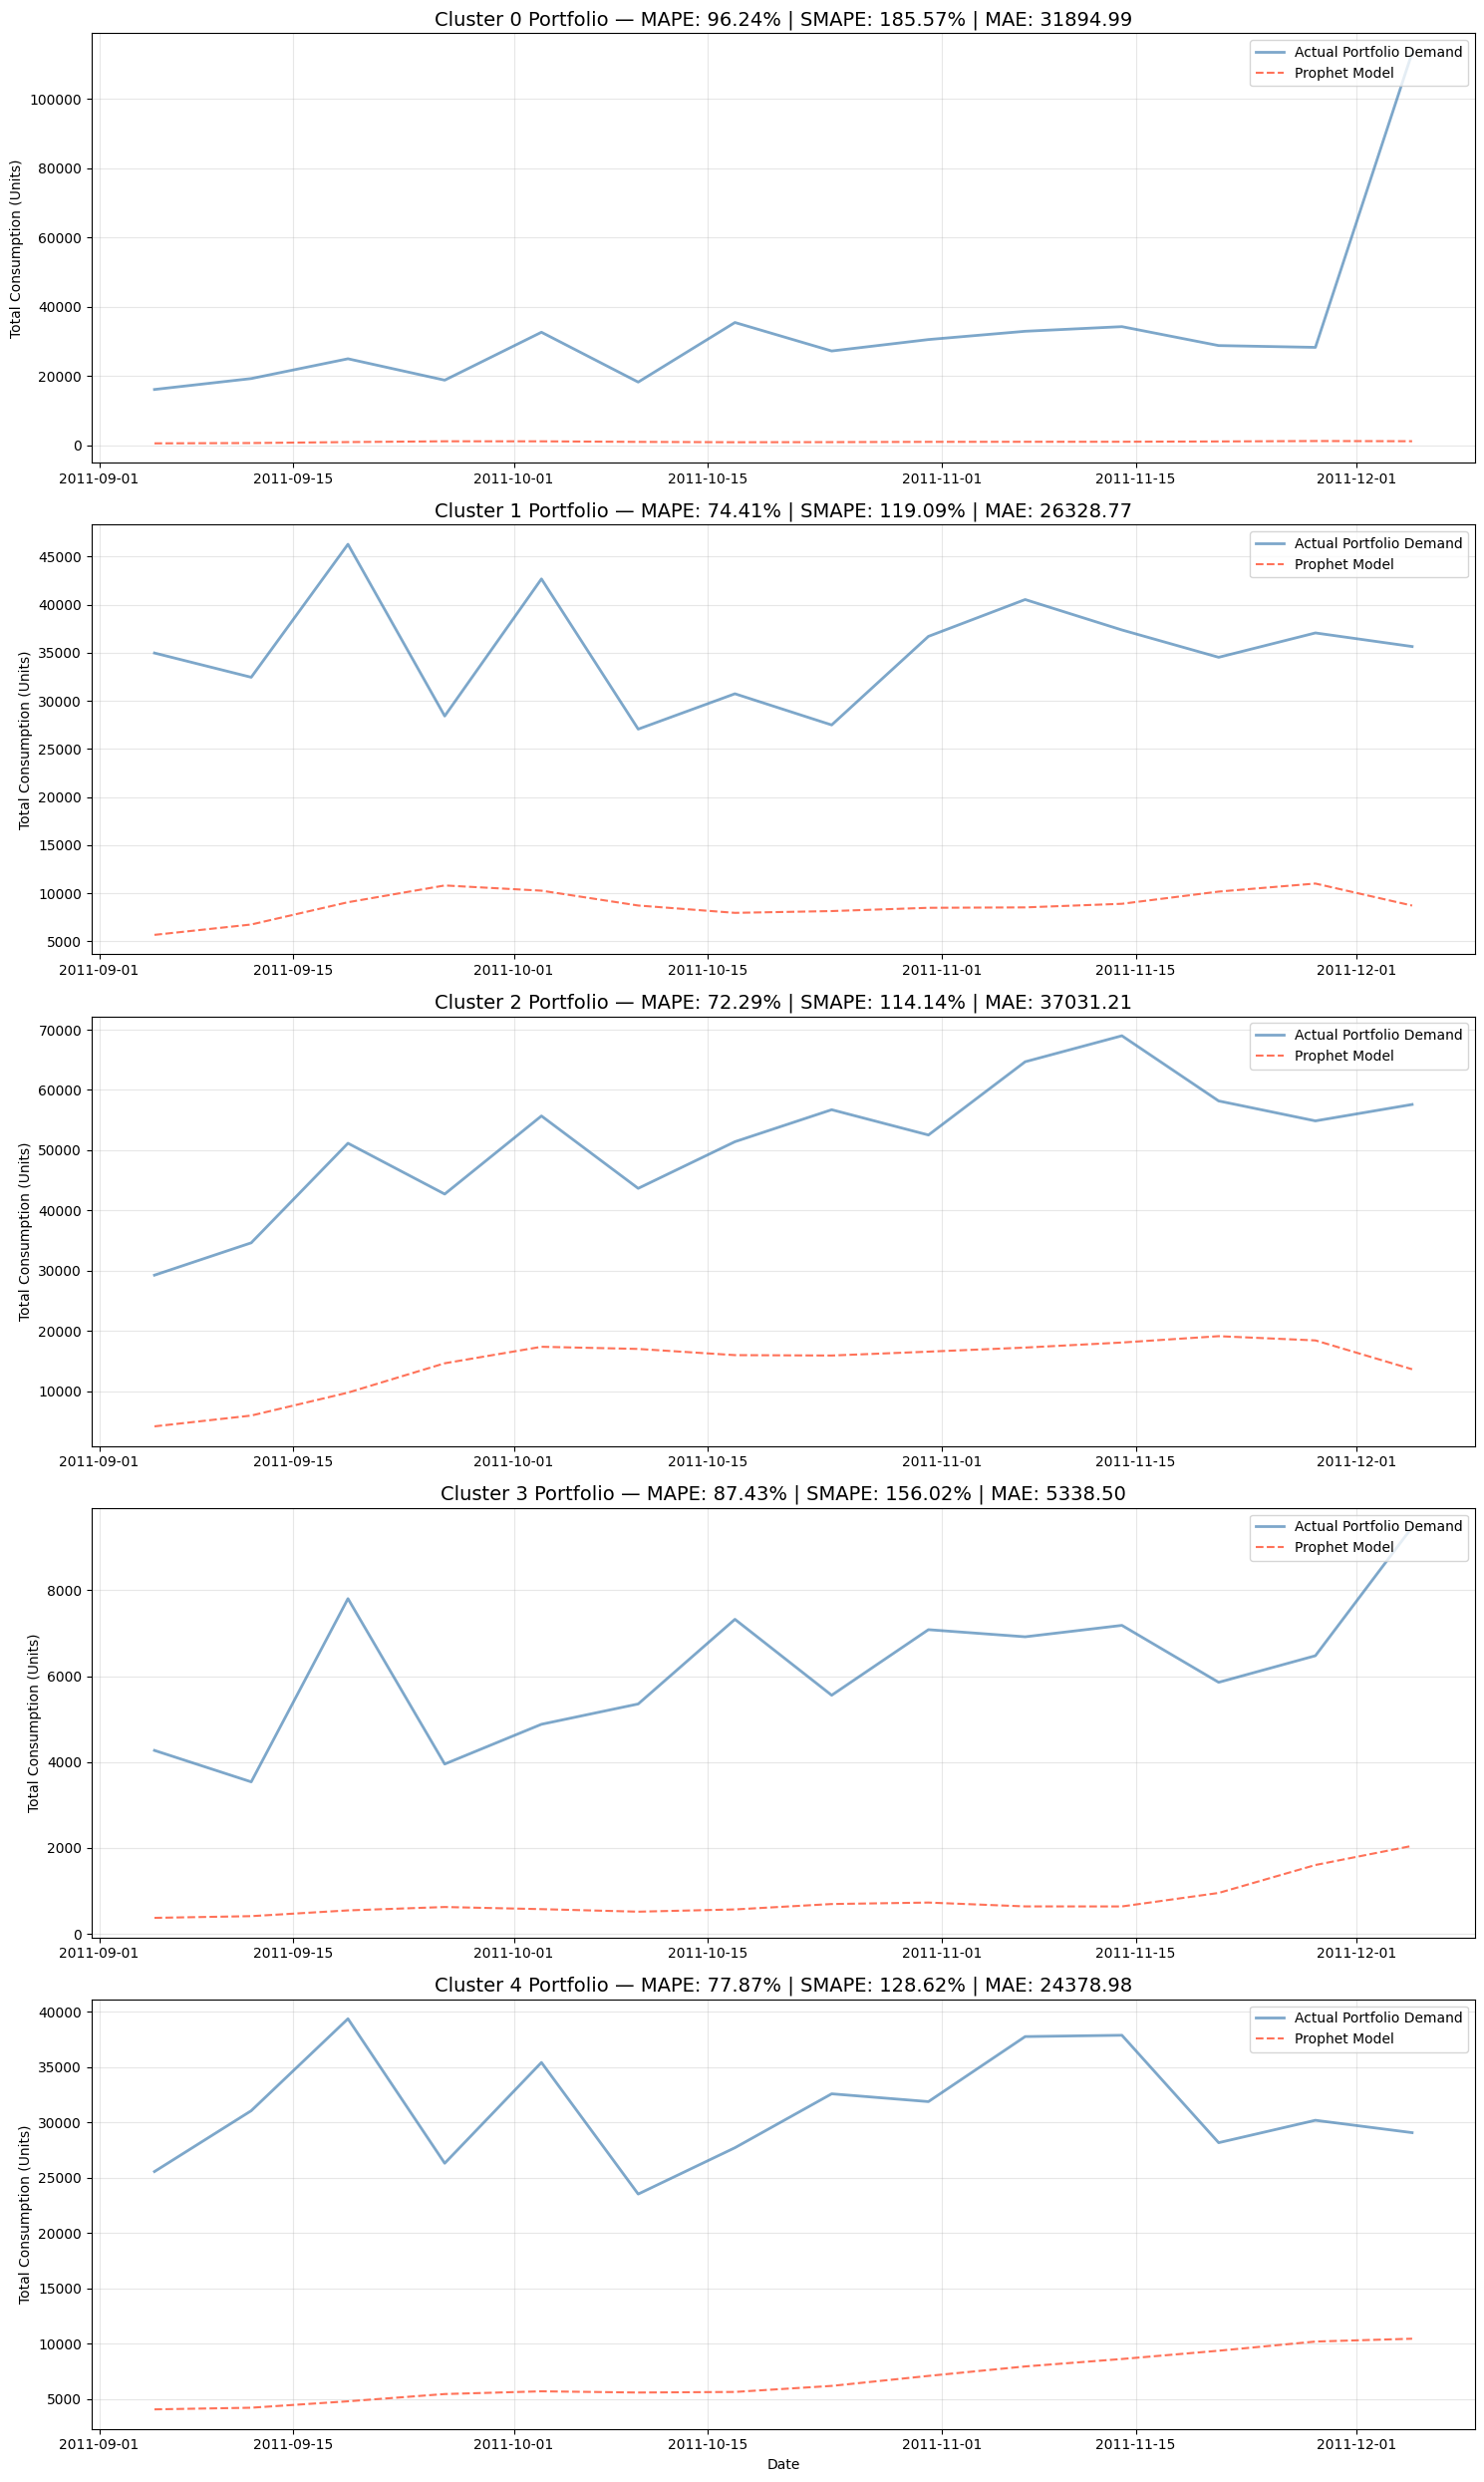

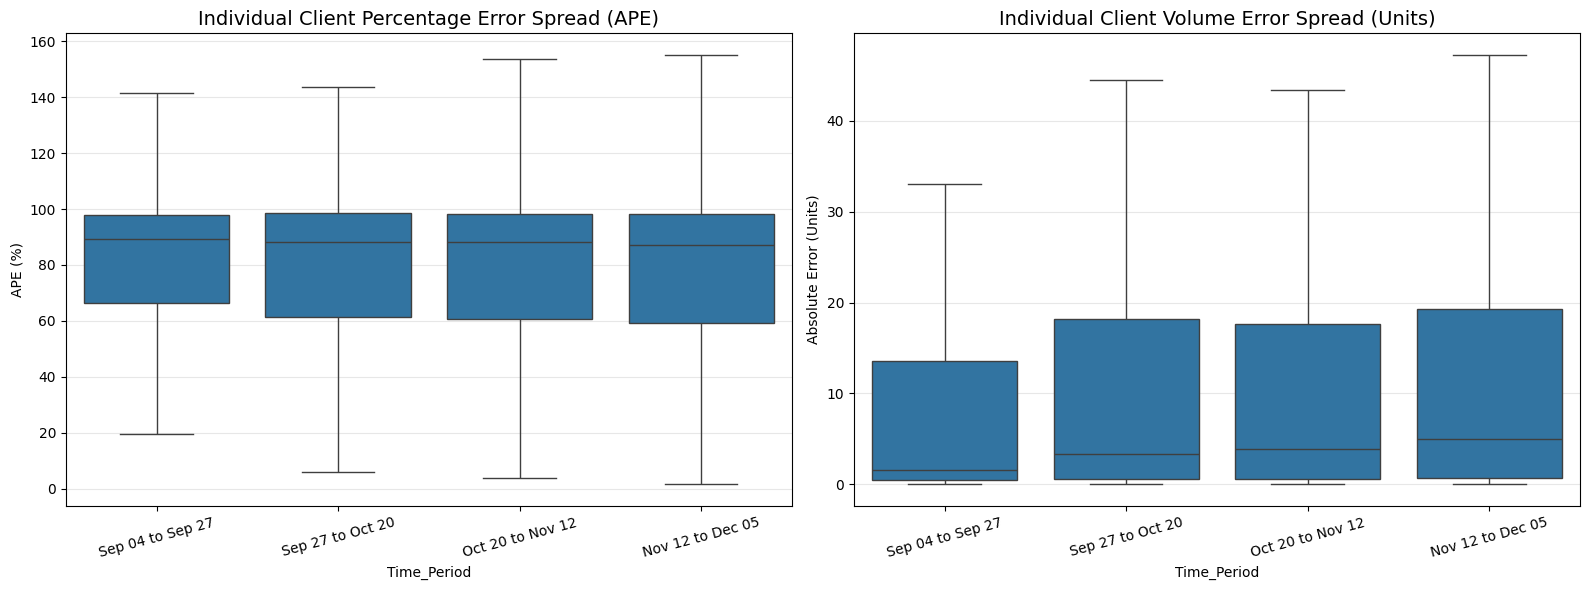

,MAPE,SMAPE,MAE
Time_Period,,,
Sep 04 to Sep 27,128.46,170.12,26.23
Sep 27 to Oct 20,163.15,166.72,29.82
Oct 20 to Nov 12,154.23,164.48,33.04
Nov 12 to Dec 05,160.42,162.03,37.73


In [4]:
plot_cluster_portfolio(portfolio_eval, summary, model_label="Prophet Model")
analyze_time_periods(test_raw)